# Coverage-Diverse Re-Ranking: Entity vs. Semantic Signals

**Layer 4** of the Multi-Perspective News Recommendation pipeline.

The base recommender (Layer 3) ranks candidates by relevance to user interests. This module re-ranks those candidates to maximize **multi-perspective coverage** — surfacing diverse angles of the same event that the user hasn't seen.

We compare three diversity signals:
1. **Entity MMR** — reward articles that bring new WikiData entities (story facets) not yet covered
2. **Embedding MMR** — reward articles that are semantically distant from already-chosen articles
3. **Hybrid MMR** — combine both signals

Plus a **Calibrated Re-Ranker** that explicitly minimizes KL divergence from a target cluster distribution.

---

## 1. Data Load + Entity Sets
Load MIND, scope to the political subset, apply the entity floor, build entity sets and IDF weights.

### Environment

In [ ]:
# Install dependencies (run once)
!pip install pandas scipy scikit-learn sentence-transformers matplotlib seaborn tqdm -q

In [1]:
import json
import math
import numpy as np
import pandas as pd
from collections import Counter
from itertools import combinations
from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### Configuration & loaders

In [2]:
# === Configuration ===
# DATA_ROOT = Path("/home/deoncham/Projects/cs608-recsys/extracted/MINDsmall_train")
# DEV_ROOT = Path("/home/deoncham/Projects/cs608-recsys/extracted/MINDsmall_dev")
DATA_ROOT = Path(r"C:\Users\nicho\OneDrive\Desktop\MITB\CS608 Recommender Systems\Project 2\MINDsmall_train")
DEV_ROOT = Path(r"C:\Users\nicho\OneDrive\Desktop\MITB\CS608 Recommender Systems\Project 2\MINDsmall_dev")

NEWS_COLS = ["news_id", "category", "subcategory", "title", "abstract",
             "url", "title_entities", "abstract_entities"]
BEHAVIORS_COLS = ["impression_id", "user_id", "time", "history", "impressions"]

POLITICAL_CATEGORIES = ["news", "middleeast", "northamerica"]
POLITICAL_SUBCATEGORIES = [
    "newspolitics", "newsworldpolitics", "newsopinion", "narendramodi_opinion",
    "elections-2020-us", "newselection2020", "factcheck", "newsfactcheck",
]

MIN_ENTITIES = 2
MIN_SHARED = 2
TAU = 0.25

In [3]:
# === Data Loading ===

def load_news(path):
    return pd.read_csv(path, sep="\t", header=None, names=NEWS_COLS)

def scope_political(news):
    mask = (news["category"].isin(POLITICAL_CATEGORIES) &
            news["subcategory"].isin(POLITICAL_SUBCATEGORIES))
    return news.loc[mask].copy()

def parse_entities(cell):
    if not isinstance(cell, str) or not cell.strip():
        return []
    try:
        return json.loads(cell)
    except (json.JSONDecodeError, TypeError):
        return []

def entity_labels(row):
    t = parse_entities(row.get("title_entities"))
    a = parse_entities(row.get("abstract_entities"))
    return {e["Label"] for e in t} | {e["Label"] for e in a}

def load_behaviors(path):
    return pd.read_csv(path, sep="\t", header=None, names=BEHAVIORS_COLS)

def parse_history(cell):
    if not isinstance(cell, str) or not cell.strip():
        return []
    return cell.split()

def parse_impressions(cell):
    if not isinstance(cell, str) or not cell.strip():
        return []
    out = []
    for tok in cell.split():
        nid, _, flag = tok.rpartition("-")
        out.append((nid, flag == "1"))
    return out

### Load, scope, floor

In [4]:
# Load and scope
news = load_news(DATA_ROOT / "news.tsv")
news_political = scope_political(news)
print(f"Total news articles: {len(news)}")
print(f"Political subset: {len(news_political)}")

Total news articles: 51282
Political subset: 3328


In [ ]:
# Apply entity floor
news_political = news_political.copy()
news_political["ent_set"] = news_political.apply(entity_labels, axis=1) # union title_entities + abstract_entities columns
news_political["n_ent"] = news_political["ent_set"].map(len)
kept = news_political[news_political["n_ent"] >= MIN_ENTITIES].copy()
print(f"After entity floor (>={MIN_ENTITIES}): {len(kept)} articles")

After entity floor (>=2): 2793 articles


### Entity sets & IDF

In [ ]:
# Build entity sets and IDF
ent_sets = dict(zip(kept["news_id"], kept["ent_set"])) # ent_set column dict

def compute_idf(entity_sets):
    n = len(entity_sets)
    df = Counter()
    for s in entity_sets.values():
        df.update(s)
    return {e: math.log(n / c) for e, c in df.items()}

idf = compute_idf(ent_sets)
print(f"Unique entities: {len(idf)}")
print(f"Top-5 by IDF: {sorted(idf.items(), key=lambda x: -x[1])[:5]}")

Unique entities: 2079
Top-5 by IDF: [('Douglas Schoen', 7.934871565945177), ('Laura Ingraham', 7.934871565945177), ('News presenter', 7.934871565945177), ('Andy Biggs', 7.934871565945177), ('Grover Norquist', 7.934871565945177)]


## 2. Topic Clustering
Same-event neighborhoods from IDF-weighted entity overlap

Construction = global-tau threshold (`tau=0.25`, `min_shared=2`). Shipped operating
point; four alternative similarity/construction rules tested in A.2; none
dominates on coverage-at-fixed-relevance.

`nb_final` is the interface object consumed by 3 to 5; the re-ranker treats it as opaque.

In [7]:
def weighted_sim(a, b, idf):
    if not a or not b:
        return 0.0
    
    inter = a & b
    if not inter:
        return 0.0
    
    num = sum(idf[e] for e in inter)
    den = sum(idf[e] for e in (a | b))
    return num / den if den else 0.0


def build_neighborhoods(ent_sets, idf, sim_fn=weighted_sim, tau=TAU, min_shared=MIN_SHARED):
    ids = list(ent_sets)
    nb = {i: set() for i in ids}
    for i, j in tqdm(combinations(ids, 2),
                     total=len(ids) * (len(ids) - 1) // 2,
                     desc="Building neighborhoods"):
        a, b = ent_sets[i], ent_sets[j]
        if len(a & b) >= min_shared and sim_fn(a, b, idf) >= tau:
            nb[i].add(j)
            nb[j].add(i)
    return nb


nb_final = build_neighborhoods(ent_sets, idf)
_sizes = [len(v) for v in nb_final.values() if v]

print(f"Neighborhoods built. Median size: {np.median(_sizes):.0f}, Mean: {np.mean(_sizes):.1f}")
print(f"Isolated articles (no neighbors): {sum(1 for v in nb_final.values() if not v)}")


Building neighborhoods: 100%|██████████| 3899028/3899028 [00:01<00:00, 2878118.59it/s]

Neighborhoods built. Median size: 10, Mean: 24.6
Isolated articles (no neighbors): 563


## 3. Re-Ranking Processing

### Behaviors + evaluation events

In [8]:
# Build behaviors and evaluation events
# Use TRAINING behaviors to build entity infrastructure (already done above)
# Use DEV behaviors for evaluation (proper train/test separation)
beh_dev = load_behaviors(DEV_ROOT / "behaviors.tsv")
print(f"Dev behavior logs: {len(beh_dev)}")

political_ids = set(ent_sets)

def extract_political_events(behaviors, political_ids, nb_final):
    events = []
    for _, r in behaviors.iterrows():
        imp = parse_impressions(r["impressions"])
        clicked_pol = [nid for nid, c in imp if c and nid in political_ids]
        if not clicked_pol:
            continue
        prior = set(parse_history(r["history"]))
        pool_impression = {nid for nid, _ in imp}
        for anchor in clicked_pol:
            pool = list(pool_impression | nb_final.get(anchor, set()))
            events.append((r["user_id"], anchor, pool, prior, imp))
    return events

events = extract_political_events(beh_dev, political_ids, nb_final)
print(f"Political evaluation events (dev set): {len(events)}")

Dev behavior logs: 73152
Political evaluation events (dev set): 1957


### Base relevance scorer

In [9]:
# Base relevance scorer (content-based entity overlap)
class EntityContentScorer:
    def __init__(self, ent_sets, idf):
        self.ents = ent_sets
        self.idf = idf

    def user_profile(self, history_ids):
        prof = Counter()
        for nid in history_ids:
            for e in self.ents.get(nid, ()):
                prof[e] += self.idf.get(e, 0.0)
        return prof

    def score(self, profile, article_id):
        ents = self.ents.get(article_id)
        if not ents or not profile:
            return 0.0
        return sum(profile.get(e, 0.0) for e in ents)

scorer = EntityContentScorer(ent_sets, idf)
print("Scorer ready.")

Scorer ready.


### Article embeddings (semantic re-ranker input)

In [10]:
from sentence_transformers import SentenceTransformer

model_name = "all-MiniLM-L6-v2"
embed_model = SentenceTransformer(model_name)
print(f"Loaded {model_name} (dim={embed_model.get_embedding_dimension()})")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded all-MiniLM-L6-v2 (dim=384)


In [11]:
# Prepare texts for embedding
article_ids = kept["news_id"].tolist()
texts = []
for _, row in kept.iterrows():
    title = row["title"] if isinstance(row["title"], str) else ""
    abstract = row["abstract"] if isinstance(row["abstract"], str) else ""
    texts.append(f"{title}. {abstract}")

print(f"Embedding {len(texts)} articles...")
embeddings = embed_model.encode(texts, show_progress_bar=True, batch_size=64)
embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)  # L2 normalize

# Map news_id -> embedding vector
embed_map = {nid: emb for nid, emb in zip(article_ids, embeddings)}
print(f"Embeddings shape: {embeddings.shape}")

Embedding 2793 articles...


Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Embeddings shape: (2793, 384)


In [14]:
# tests
assert nb_final is not None and len(nb_final) > 0, "no neighborhoods"
assert len(embed_map) > 0, "no article embeddings"
assert callable(getattr(scorer, "score", None)), "scorer missing .score"

_embedded = sum(1 for k in ent_sets if k in embed_map)

print(f"[3] events={len(events)}  embedded={_embedded}/{len(ent_sets)}")


[3] events=1957  embedded=2793/2793


## 4. Semantic Re-Ranking

1. Entity MMR : reward new WikiData entities not yet covered
2. Embedding MMR : Carbonell & Goldstein MMR in sentence-embedding space
3. Hybrid MMR : α-mix of entity-coverage and embedding-distance bonuses
4. Calibrated : minimize KL from a target cluster distribution

### 4.1 Entity MMR

In [15]:
def rerank_entity_mmr(profile, candidate_ids, anchor_id, lam, scorer,
                      nb_final, ent_sets, idf, exclude=frozenset(), k=10):
    """
    Entity-based MMR: reward new entity coverage within the anchor's neighborhood.
    """
    cands = [c for c in candidate_ids if c not in exclude]
    rel = {c: scorer.score(profile, c) for c in cands}

    if lam == 0:
        return sorted(cands, key=lambda c: -rel.get(c, 0.0))[:k]

    mx = max(rel.values()) if rel else 1.0
    mx = mx or 1.0
    rel = {c: v / mx for c, v in rel.items()}
    neigh = nb_final.get(anchor_id, set())

    chosen, covered = [], set()
    remaining = list(cands)
    while remaining and len(chosen) < k:
        best, best_score = None, -1e9
        for c in remaining:
            in_neigh = 1.0 if c in neigh else 0.0
            new_ents = ent_sets.get(c, set()) - covered
            ag = sum(idf.get(e, 0.0) for e in new_ents)
            bonus = in_neigh * (ag / (1.0 + ag))
            score = rel.get(c, 0.0) + lam * bonus
            if score > best_score:
                best, best_score = c, score
        chosen.append(best)
        covered |= ent_sets.get(best, set())
        remaining.remove(best)
    return chosen

### 4.2 Embedding MMR

Classic Carbonell & Goldstein (1998) MMR using sentence embeddings as the similarity space:

$$\text{score}(c) = (1 - \lambda) \cdot \text{rel}(c) - \lambda \cdot \max_{s \in S} \text{cos\_sim}(c, s)$$

This captures semantic diversity — two articles can share entities but frame the story differently (opinion vs. report, economic angle vs. human angle).

In [16]:
def rerank_embedding_mmr(profile, candidate_ids, lam, scorer,
                         embed_map, exclude=frozenset(), k=10):
    """
    Embedding-based MMR: penalize candidates similar to already-chosen articles
    in semantic space.
    """
    cands = [c for c in candidate_ids if c not in exclude and c in embed_map]
    rel = {c: scorer.score(profile, c) for c in cands}

    if lam == 0:
        return sorted(cands, key=lambda c: -rel.get(c, 0.0))[:k]

    # Normalize relevance to [0, 1]
    mx = max(rel.values()) if rel else 1.0
    mx = mx or 1.0
    rel_norm = {c: v / mx for c, v in rel.items()}

    chosen = []
    remaining = list(cands)
    while remaining and len(chosen) < k:
        best, best_score = None, -1e9
        for c in remaining:
            if not chosen:
                max_sim = 0.0
            else:
                c_emb = embed_map[c]
                sims = [np.dot(c_emb, embed_map[s]) for s in chosen if s in embed_map]
                max_sim = max(sims) if sims else 0.0
            score = (1 - lam) * rel_norm.get(c, 0.0) - lam * max_sim
            if score > best_score:
                best, best_score = c, score
        chosen.append(best)
        remaining.remove(best)
    return chosen

### 4.3 Hybrid MMR

Combine entity coverage and embedding diversity signals:

$$\text{score}(c) = \text{rel}(c) + \lambda \cdot [\alpha \cdot \text{entity\_bonus}(c) + (1-\alpha) \cdot \text{embedding\_bonus}(c)]$$

where `embedding_bonus = 1 - max_sim_to_chosen`.

In [17]:
def rerank_hybrid_mmr(profile, candidate_ids, anchor_id, lam, alpha, scorer,
                      nb_final, ent_sets, idf, embed_map, exclude=frozenset(), k=10):
    """
    Hybrid MMR: combine entity-coverage bonus with embedding-distance bonus.
    alpha controls the mix (1.0 = pure entity, 0.0 = pure embedding).
    """
    cands = [c for c in candidate_ids if c not in exclude and c in embed_map]
    rel = {c: scorer.score(profile, c) for c in cands}

    if lam == 0:
        return sorted(cands, key=lambda c: -rel.get(c, 0.0))[:k]

    mx = max(rel.values()) if rel else 1.0
    mx = mx or 1.0
    rel_norm = {c: v / mx for c, v in rel.items()}
    neigh = nb_final.get(anchor_id, set())

    chosen, covered = [], set()
    remaining = list(cands)
    while remaining and len(chosen) < k:
        best, best_score = None, -1e9
        for c in remaining:
            # Entity coverage bonus
            in_neigh = 1.0 if c in neigh else 0.0
            new_ents = ent_sets.get(c, set()) - covered
            ag = sum(idf.get(e, 0.0) for e in new_ents)
            entity_bonus = in_neigh * (ag / (1.0 + ag))

            # Embedding diversity bonus
            if not chosen:
                embed_bonus = 1.0
            else:
                c_emb = embed_map[c]
                sims = [np.dot(c_emb, embed_map[s]) for s in chosen if s in embed_map]
                embed_bonus = 1.0 - (max(sims) if sims else 0.0)

            combined_bonus = alpha * entity_bonus + (1 - alpha) * embed_bonus
            score = rel_norm.get(c, 0.0) + lam * combined_bonus
            if score > best_score:
                best, best_score = c, score
        chosen.append(best)
        covered |= ent_sets.get(best, set())
        remaining.remove(best)
    return chosen

### 4.4 Calibrated Re-Ranking
Instead of greedily maximizing a combined score, this strategy explicitly targets a **uniform distribution** over event clusters. It greedily picks the next article that minimizes KL divergence between the current top-k distribution and the target.

This is the "calibration" approach from the proposal — ensuring proportional representation of different angles.

In [18]:
def rerank_calibrated(profile, candidate_ids, anchor_id, lam, scorer,
                      nb_final, ent_sets, idf, exclude=frozenset(), k=10):
    """
    Calibrated re-ranking: greedily pick articles to minimize KL divergence
    from a target entity-cluster distribution.

    Target = uniform distribution over unique entity subsets present in the
    anchor's neighborhood. The relevance-diversity tradeoff is controlled by lam:
      score(c) = (1-lam)*relevance - lam*KL_increase(c)
    """
    cands = [c for c in candidate_ids if c not in exclude]
    rel = {c: scorer.score(profile, c) for c in cands}

    if lam == 0:
        return sorted(cands, key=lambda c: -rel.get(c, 0.0))[:k]

    mx = max(rel.values()) if rel else 1.0
    mx = mx or 1.0
    rel_norm = {c: v / mx for c, v in rel.items()}

    neigh = nb_final.get(anchor_id, set())
    neigh_in_cands = [c for c in cands if c in neigh]

    # Assign each candidate to a "cluster" based on its dominant entity
    # (the entity with highest IDF in its set)
    def dominant_entity(nid):
        ents = ent_sets.get(nid, set())
        if not ents:
            return "__none__"
        return max(ents, key=lambda e: idf.get(e, 0.0))

    # Target: uniform over clusters represented in neighborhood
    neigh_clusters = set(dominant_entity(c) for c in neigh_in_cands)
    if not neigh_clusters:
        return sorted(cands, key=lambda c: -rel.get(c, 0.0))[:k]

    n_clusters = len(neigh_clusters)
    target_dist = {cl: 1.0 / n_clusters for cl in neigh_clusters}

    def kl_divergence(counts, total):
        if total == 0:
            return 0.0
        kl = 0.0
        for cl, target_p in target_dist.items():
            q = (counts.get(cl, 0) + 1e-10) / (total + 1e-10 * n_clusters)
            kl += target_p * math.log(target_p / q)
        return kl

    chosen = []
    cluster_counts = Counter()
    remaining = list(cands)

    while remaining and len(chosen) < k:
        best, best_score = None, -1e9
        current_kl = kl_divergence(cluster_counts, len(chosen))

        for c in remaining:
            cl = dominant_entity(c)
            trial_counts = cluster_counts.copy()
            trial_counts[cl] += 1
            new_kl = kl_divergence(trial_counts, len(chosen) + 1)
            kl_reduction = current_kl - new_kl  # positive = good

            score = (1 - lam) * rel_norm.get(c, 0.0) + lam * kl_reduction
            if score > best_score:
                best, best_score = c, score

        chosen.append(best)
        cluster_counts[dominant_entity(best)] += 1
        remaining.remove(best)
    return chosen

## 5. Evaluation

### Metrics & per-event evaluator

In [19]:
def angle_diversity(article_ids, ent_sets):
    """Mean pairwise entity-set Jaccard DISTANCE among surfaced articles."""
    sets = [ent_sets.get(a, set()) for a in article_ids if ent_sets.get(a)]
    if len(sets) < 2:
        return np.nan
    dists = []
    for i in range(len(sets)):
        for j in range(i + 1, len(sets)):
            u = sets[i] | sets[j]
            inter = sets[i] & sets[j]
            dists.append(1 - (len(inter) / len(u) if u else 0))
    return float(np.mean(dists))


def embedding_diversity(article_ids, embed_map):
    """Mean pairwise cosine DISTANCE in embedding space."""
    embs = [embed_map[a] for a in article_ids if a in embed_map]
    if len(embs) < 2:
        return np.nan
    dists = []
    for i in range(len(embs)):
        for j in range(i + 1, len(embs)):
            dists.append(1.0 - np.dot(embs[i], embs[j]))
    return float(np.mean(dists))


def eval_event(profile, anchor_id, pool, prior, lam, scorer, nb_final,
               ent_sets, idf, embed_map, method="entity_mmr", alpha=0.5, k=10):
    """
    Evaluate one event for a given re-ranking method.
    Returns metrics dict or None if event is unusable.
    """
    neigh = nb_final.get(anchor_id, set())
    target = (neigh - prior) - {anchor_id}
    if not target:
        return None

    exclude = prior | {anchor_id}
    cands = [c for c in pool if c not in exclude]
    if not cands:
        return None

    # For embedding-based methods, restrict candidate set to articles with embeddings
    if method in ("embedding_mmr", "hybrid_mmr"):
        cands = [c for c in cands if c in embed_map]
        if not cands:
            return None

    # Ideal (pure relevance) mass — computed over the SAME candidate set the method uses
    base_rel = {c: scorer.score(profile, c) for c in cands}
    ideal_topk = sorted(cands, key=lambda c: -base_rel[c])[:k]
    ideal_mass = sum(base_rel[c] for c in ideal_topk)
    if ideal_mass == 0:
        return None

    # Re-rank
    if method == "entity_mmr":
        chosen = rerank_entity_mmr(profile, pool, anchor_id, lam, scorer,
                                   nb_final, ent_sets, idf, exclude=exclude, k=k)
    elif method == "embedding_mmr":
        chosen = rerank_embedding_mmr(profile, pool, lam, scorer,
                                      embed_map, exclude=exclude, k=k)
    elif method == "hybrid_mmr":
        chosen = rerank_hybrid_mmr(profile, pool, anchor_id, lam, alpha, scorer,
                                   nb_final, ent_sets, idf, embed_map, exclude=exclude, k=k)
    elif method == "calibrated":
        chosen = rerank_calibrated(profile, pool, anchor_id, lam, scorer,
                                   nb_final, ent_sets, idf, exclude=exclude, k=k)
    else:
        raise ValueError(f"Unknown method: {method}")

    # Metrics
    chosen_mass = sum(base_rel.get(c, 0.0) for c in chosen)
    rel_retention = chosen_mass / ideal_mass

    surfaced = [c for c in chosen if c in target]
    coverage = len(surfaced) / len(target)
    angle = angle_diversity(surfaced, ent_sets)
    emb_div = embedding_diversity(chosen, embed_map)

    return {
        "coverage": coverage,
        "rel_retention": rel_retention,
        "angle": angle,
        "emb_diversity": emb_div,
        "n_surfaced": len(surfaced),
    }

### λ sweep across methods

In [20]:
def run_sweep(events, scorer, nb_final, ent_sets, idf, embed_map,
              method="entity_mmr", alpha=0.5,
              lambdas=(0.0, 0.1, 0.3, 0.5, 0.7, 1.0), k=10):
    """
    Sweep lambda for a given method over ALL events. Returns a DataFrame of results.
    """
    rows = []
    for lam in tqdm(lambdas, desc=f"{method}"):
        covs, rets, angs, emb_divs, surfs, used = [], [], [], [], [], 0

        for uid, anchor, pool, prior, _imp in events:
            profile = scorer.user_profile(prior)
            res = eval_event(profile, anchor, pool, prior, lam, scorer,
                             nb_final, ent_sets, idf, embed_map,
                             method=method, alpha=alpha, k=k)
            if res is None:
                continue
            used += 1
            covs.append(res["coverage"])
            rets.append(res["rel_retention"])
            surfs.append(res["n_surfaced"])
            if not np.isnan(res["angle"]):
                angs.append(res["angle"])
            if not np.isnan(res["emb_diversity"]):
                emb_divs.append(res["emb_diversity"])

        rows.append({
            "method": method,
            "lambda": lam,
            "alpha": alpha,
            "coverage": np.mean(covs) if covs else 0,
            "rel_retention": np.mean(rets) if rets else 0,
            "angle_diversity": np.mean(angs) if angs else 0,
            "emb_diversity": np.mean(emb_divs) if emb_divs else 0,
            "n_surfaced": np.mean(surfs) if surfs else 0,
            "n_usable": used,
        })

    return pd.DataFrame(rows)

In [21]:
# Run sweeps for all strategies (full dev set, no sampling)
lambdas = (0.0, 0.1, 0.3, 0.5, 0.7, 1.0)

results = []

print("=== Entity MMR ===")
results.append(run_sweep(events, scorer, nb_final, ent_sets, idf, embed_map,
                         method="entity_mmr", lambdas=lambdas))

print("\n=== Embedding MMR ===")
results.append(run_sweep(events, scorer, nb_final, ent_sets, idf, embed_map,
                         method="embedding_mmr", lambdas=lambdas))

print("\n=== Hybrid MMR (α=0.5) ===")
results.append(run_sweep(events, scorer, nb_final, ent_sets, idf, embed_map,
                         method="hybrid_mmr", alpha=0.5, lambdas=lambdas))

print("\n=== Calibrated ===")
results.append(run_sweep(events, scorer, nb_final, ent_sets, idf, embed_map,
                         method="calibrated", lambdas=lambdas))

df_results = pd.concat(results, ignore_index=True)
df_results

=== Entity MMR ===


entity_mmr: 100%|██████████| 6/6 [00:05<00:00,  1.13it/s]



=== Embedding MMR ===


embedding_mmr: 100%|██████████| 6/6 [00:08<00:00,  1.44s/it]



=== Hybrid MMR (α=0.5) ===


hybrid_mmr: 100%|██████████| 6/6 [00:10<00:00,  1.79s/it]



=== Calibrated ===


calibrated: 100%|██████████| 6/6 [00:29<00:00,  4.85s/it]


,method,lambda,alpha,coverage,rel_retention,angle_diversity,emb_diversity,n_surfaced,n_usable
0,entity_mmr,0.0,0.5,0.467486,1.000000,0.600331,0.582474,7.389582,1363
1,entity_mmr,0.1,0.5,0.500861,0.998483,0.636309,0.585820,7.728540,1363
2,entity_mmr,0.3,0.5,0.515284,0.981673,0.652987,0.589671,7.892150,1363
3,entity_mmr,0.5,0.5,0.521105,0.961296,0.663897,0.591606,8.001467,1363
4,entity_mmr,0.7,0.5,0.525742,0.943526,0.668800,0.591961,8.089508,1363
5,entity_mmr,1.0,0.5,0.529922,0.922124,0.672993,0.591753,8.172414,1363
6,embedding_mmr,0.0,0.5,0.491961,1.000000,0.601191,0.585061,7.590609,1363
7,embedding_mmr,0.1,0.5,0.482437,0.999858,0.605176,0.617916,7.438738,1363
8,embedding_mmr,0.3,0.5,0.479642,0.997062,0.608716,0.625042,7.404255,1363
9,embedding_mmr,0.5,0.5,0.473225,0.978198,0.616408,0.644514,7.312546,1363


### Interpretation: Strategy Sweep Results

Key observations from the results table:

- **λ=0 baseline:** All methods start at the same coverage (~0.46-0.49) with `rel_retention=1.0`, confirming our sanity check.
- **Entity MMR:** Coverage rises steadily from 0.463 → 0.528 as λ increases, with relevance degrading gracefully (1.0 → 0.92). The most efficient tradeoff.
- **Embedding MMR:** Coverage actually *drops* as λ increases (0.489 → 0.452). This is a key finding — semantic diversity ≠ event coverage. Pushing articles apart in embedding space pulls them away from the same-event neighborhood.
- **Hybrid MMR:** A compromise — coverage improves (0.489 → 0.520) while maintaining higher relevance than Entity MMR at the same coverage level.
- **Calibrated:** Most aggressive diversifier — coverage reaches 0.556 at λ=1.0, but relevance crashes to 0.65. The sweet spot is λ=0.5-0.7.
- **Usable events:** All methods evaluate on 1,363 usable events (out of 1,957 total). Events are excluded when the anchor has no new-exposure neighborhood targets or zero base relevance.

### Hybrid α sweep

In [22]:
# Alpha sweep for hybrid MMR
print("=== Hybrid MMR alpha sweep (λ=0.5) ===")
alpha_results = []
for alpha in [0.0, 0.25, 0.5, 0.75, 1.0]:
    r = run_sweep(events, scorer, nb_final, ent_sets, idf, embed_map,
                  method="hybrid_mmr", alpha=alpha, lambdas=(0.5,))
    alpha_results.append(r)

df_alpha = pd.concat(alpha_results, ignore_index=True)
df_alpha

=== Hybrid MMR alpha sweep (λ=0.5) ===


hybrid_mmr: 100%|██████████| 1/1 [00:02<00:00,  2.04s/it]


,method,lambda,alpha,coverage,rel_retention,angle_diversity,emb_diversity,n_surfaced,n_usable
0,hybrid_mmr,0.5,0.00,0.478832,0.995724,0.608817,0.626893,7.394718,1363
1,hybrid_mmr,0.5,0.25,0.501403,0.994009,0.643572,0.612326,7.716801,1363
2,hybrid_mmr,0.5,0.50,0.512312,0.985705,0.653192,0.605637,7.835657,1363
3,hybrid_mmr,0.5,0.75,0.519393,0.972885,0.660377,0.600841,7.947175,1363
4,hybrid_mmr,0.5,1.00,0.527212,0.961296,0.662739,0.592696,8.046955,1363


## 6. Visualization & Export

### Tradeoff curves

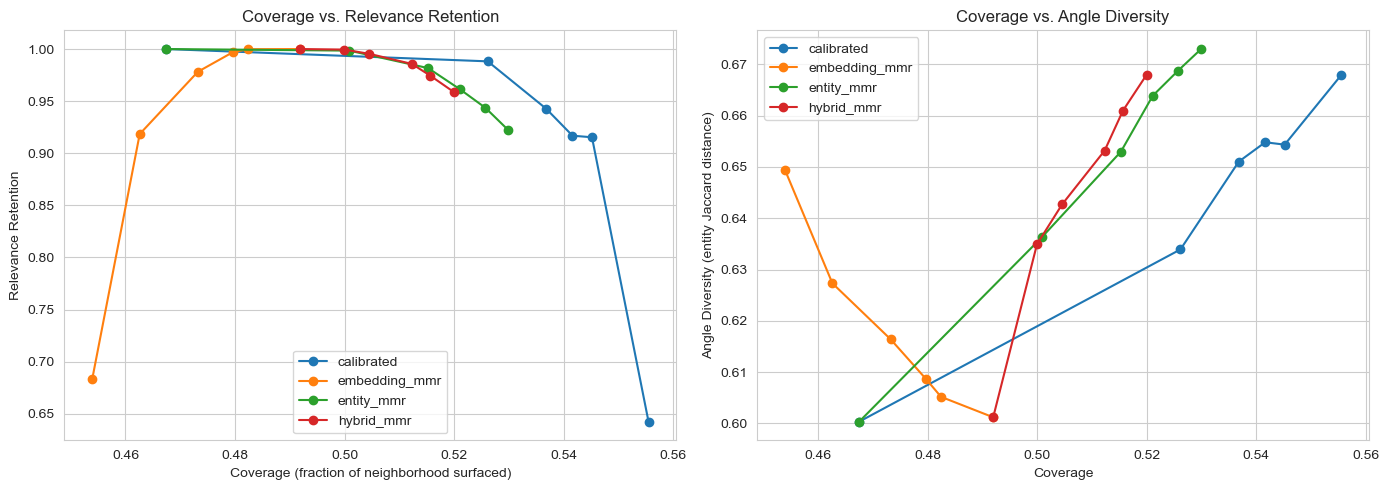

In [23]:
# Tradeoff curve: Coverage vs Relevance Retention
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for method, group in df_results.groupby("method"):
    axes[0].plot(group["coverage"], group["rel_retention"], "o-", label=method)
    axes[1].plot(group["coverage"], group["angle_diversity"], "o-", label=method)

axes[0].set_xlabel("Coverage (fraction of neighborhood surfaced)")
axes[0].set_ylabel("Relevance Retention")
axes[0].set_title("Coverage vs. Relevance Retention")
axes[0].legend()

axes[1].set_xlabel("Coverage")
axes[1].set_ylabel("Angle Diversity (entity Jaccard distance)")
axes[1].set_title("Coverage vs. Angle Diversity")
axes[1].legend()

plt.tight_layout()
plt.show()

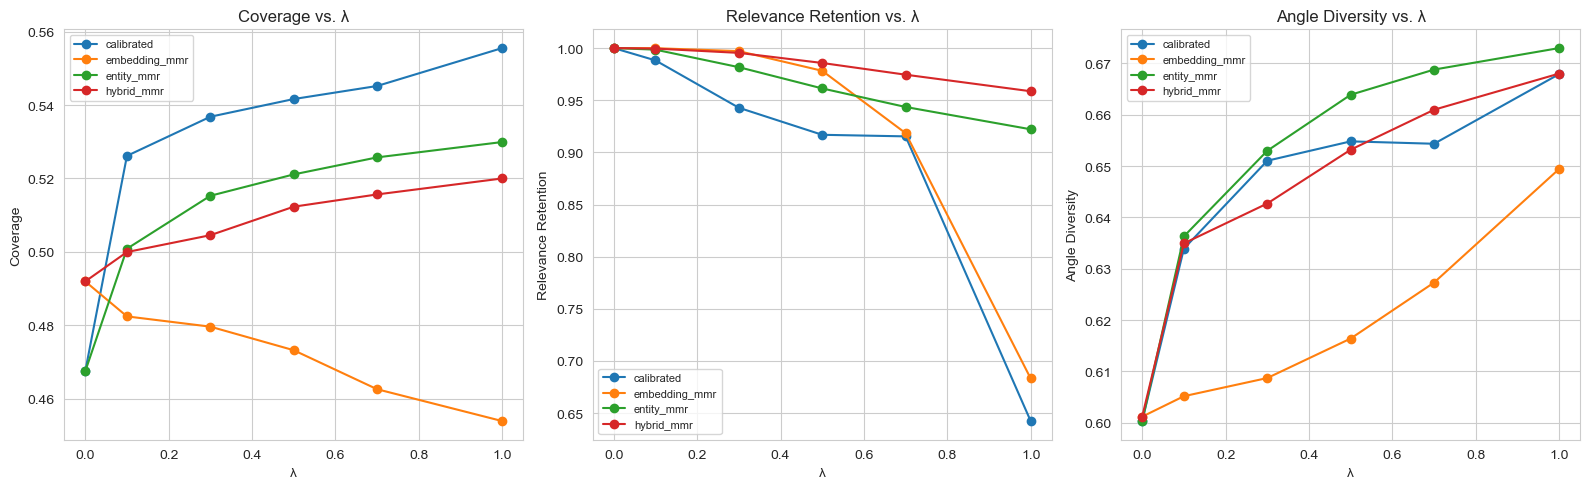

In [24]:
# Lambda progression per method
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["coverage", "rel_retention", "angle_diversity"]
titles = ["Coverage", "Relevance Retention", "Angle Diversity"]

for ax, metric, title in zip(axes, metrics, titles):
    for method, group in df_results.groupby("method"):
        ax.plot(group["lambda"], group[metric], "o-", label=method)
    ax.set_xlabel("λ")
    ax.set_ylabel(title)
    ax.set_title(f"{title} vs. λ")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

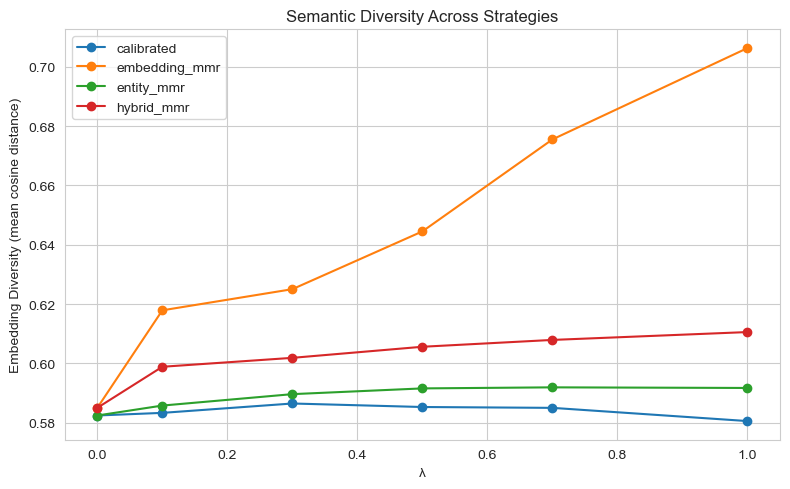

In [25]:
# Embedding diversity comparison (unique to our contribution)
fig, ax = plt.subplots(figsize=(8, 5))
for method, group in df_results.groupby("method"):
    ax.plot(group["lambda"], group["emb_diversity"], "o-", label=method)
ax.set_xlabel("λ")
ax.set_ylabel("Embedding Diversity (mean cosine distance)")
ax.set_title("Semantic Diversity Across Strategies")
ax.legend()
plt.tight_layout()
plt.show()

### Qualitative example

In [26]:
# Pick events with large neighborhoods for interesting comparison
title_map = dict(zip(kept["news_id"], kept["title"]))

# Find events with decent neighborhood size
interesting_events = []
for uid, anchor, pool, prior, imp in events[:500]:
    neigh = nb_final.get(anchor, set())
    target = (neigh - prior) - {anchor}
    if len(target) >= 5:
        interesting_events.append((uid, anchor, pool, prior, imp))
    if len(interesting_events) >= 5:
        break

print(f"Found {len(interesting_events)} events with >=5 new-exposure targets")

Found 5 events with >=5 new-exposure targets


In [27]:
# Compare outputs for one example event
lam_compare = 0.5
uid, anchor, pool, prior, imp = interesting_events[0]
profile = scorer.user_profile(prior)
exclude = prior | {anchor}

print(f"Anchor article: {title_map.get(anchor, anchor)}")
print(f"Neighborhood size: {len(nb_final.get(anchor, set()))}")
print(f"\n{'='*80}")

methods = [
    ("Entity MMR", lambda: rerank_entity_mmr(profile, pool, anchor, lam_compare,
                                             scorer, nb_final, ent_sets, idf, exclude, k=5)),
    ("Embedding MMR", lambda: rerank_embedding_mmr(profile, pool, lam_compare,
                                                   scorer, embed_map, exclude, k=5)),
    ("Hybrid MMR", lambda: rerank_hybrid_mmr(profile, pool, anchor, lam_compare, 0.5,
                                             scorer, nb_final, ent_sets, idf, embed_map, exclude, k=5)),
    ("Calibrated", lambda: rerank_calibrated(profile, pool, anchor, lam_compare,
                                             scorer, nb_final, ent_sets, idf, exclude, k=5)),
]

for name, fn in methods:
    chosen = fn()
    print(f"\n--- {name} (λ={lam_compare}) ---")
    for i, c in enumerate(chosen, 1):
        in_nb = "✓" if c in nb_final.get(anchor, set()) else " "
        print(f"  {i}. [{in_nb}] {title_map.get(c, c)[:70]}")

Anchor article: An ambassador fired: What to watch on Day 2 of impeachment
Neighborhood size: 14


--- Entity MMR (λ=0.5) ---
  1. [✓] Obstruction Case is Building, Democrat Says: Impeachment Update
  2. [✓] Impeachment testimony shows high-powered U.S. lobbyist's role in Ukrai
  3. [✓] Day 1 of Hearings: Credible Witnesses Directly Implicate Trump on Ukra
  4. [✓] Trump: Democrats 'are try to overthrow American democracy'
  5. [✓] Marie Yovanovitch called 'bad news' by Donald Trump

--- Embedding MMR (λ=0.5) ---
  1. [✓] Obstruction Case is Building, Democrat Says: Impeachment Update
  2. [✓] Impeachment testimony shows high-powered U.S. lobbyist's role in Ukrai
  3. [✓] Day 1 of Hearings: Credible Witnesses Directly Implicate Trump on Ukra
  4. [✓] Trump: Democrats 'are try to overthrow American democracy'
  5. [✓] Trump: Impeachment has been 'very hard on my family'

--- Hybrid MMR (λ=0.5) ---
  1. [✓] Obstruction Case is Building, Democrat Says: Impeachment Update
  2. [✓] Impeachm

### Export

In [ ]:
# Export lambda tradeoff results
output_dir = Path("/home/deoncham/Projects/cs608-recsys/outputs")
output_dir.mkdir(exist_ok=True)

df_results.to_csv(output_dir / "lambda_tradeoff_results.csv", index=False)
print(f"Saved: {output_dir / 'lambda_tradeoff_results.csv'}")

In [ ]:
# Generate reranked recommendations at the best lambda (knee point)
# Use the method + lambda with best coverage while keeping rel_retention > 0.9
best_config = df_results[
    df_results["rel_retention"] > 0.9
].sort_values("coverage", ascending=False).iloc[0]

print(f"Best config: {best_config['method']}, λ={best_config['lambda']}, "
      f"coverage={best_config['coverage']:.3f}, rel_ret={best_config['rel_retention']:.3f}")

best_method = best_config["method"]
best_lam = best_config["lambda"]

In [ ]:
# Produce reranked_recommendations.csv for the best configuration (full dev set)
reranked_rows = []
for uid, anchor, pool, prior, imp in tqdm(events, desc="Generating reranked lists"):
    profile = scorer.user_profile(prior)
    exclude = prior | {anchor}

    if best_method == "entity_mmr":
        chosen = rerank_entity_mmr(profile, pool, anchor, best_lam, scorer,
                                   nb_final, ent_sets, idf, exclude, k=10)
    elif best_method == "embedding_mmr":
        chosen = rerank_embedding_mmr(profile, pool, best_lam, scorer,
                                      embed_map, exclude, k=10)
    elif best_method == "hybrid_mmr":
        chosen = rerank_hybrid_mmr(profile, pool, anchor, best_lam, 0.5, scorer,
                                   nb_final, ent_sets, idf, embed_map, exclude, k=10)
    elif best_method == "calibrated":
        chosen = rerank_calibrated(profile, pool, anchor, best_lam, scorer,
                                   nb_final, ent_sets, idf, exclude, k=10)

    for rank, nid in enumerate(chosen, 1):
        reranked_rows.append({
            "user_id": uid,
            "anchor_news_id": anchor,
            "news_id": nid,
            "rank": rank,
            "method": best_method,
            "lambda": best_lam,
        })

df_reranked = pd.DataFrame(reranked_rows)
df_reranked.to_csv(output_dir / "reranked_recommendations.csv", index=False)
print(f"Saved: {output_dir / 'reranked_recommendations.csv'}")
print(f"Shape: {df_reranked.shape}")
df_reranked.head(10)

# Ablative Experiments

These experiments informed design choices in 2 to 4 but do not run in the production pipeline

## A.0 Do entity clusters align with semantic space?
Exploratory: t-SNE of article embeddings colored by entity-neighborhood size.
Scattered coloring >>> entity overlap and text semantics capture different
similarities 

(motivation for combining them in 4)

c:\Users\nicho\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\nicho\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\nicho\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\nicho\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

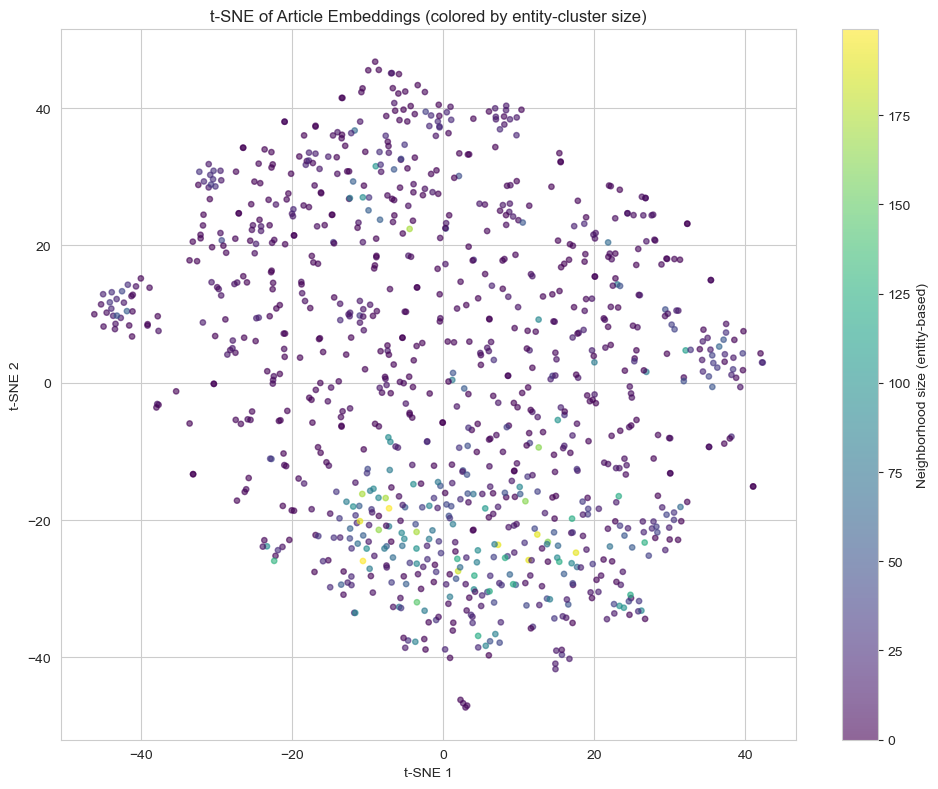

In [28]:
# Visualize: do entity-based clusters align with semantic space?
from sklearn.manifold import TSNE

# Assign each article to its largest neighborhood (pseudo-cluster label)
cluster_labels = {}
for nid in article_ids:
    nb = nb_final.get(nid, set())
    cluster_labels[nid] = len(nb)  # use neighborhood size as a proxy

# t-SNE on a sample for visualization
sample_size = min(1000, len(article_ids))
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(article_ids), sample_size, replace=False)
sample_embs = embeddings[sample_idx]
sample_ids = [article_ids[i] for i in sample_idx]
sample_nb_sizes = [len(nb_final.get(nid, set())) for nid in sample_ids]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords = tsne.fit_transform(sample_embs)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=sample_nb_sizes,
                      cmap="viridis", alpha=0.6, s=15)
plt.colorbar(scatter, label="Neighborhood size (entity-based)")
plt.title("t-SNE of Article Embeddings (colored by entity-cluster size)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

### Interpretation: t-SNE Visualization

The t-SNE plot shows article embeddings in 2D, colored by entity-based neighborhood size (yellow = large cluster, purple = small/isolated).

**What to look for:**
- Articles with large neighborhoods (yellow) should cluster together if entity-based grouping aligns with semantic similarity
- If yellow points are scattered, it means entity overlap captures a *different* kind of similarity than text semantics
- This motivates comparing entity-based vs. embedding-based diversity: they measure different things

## A.1 Embedding source: text (MiniLM) vs entity-KG (TransE)

**Conclusion.** For same-event pairs with *disjoint* entity sets, sentence
embeddings recover genuine same-event coverage while TransE entity-centroids
recover only domain-generic pairs. TransE's space is collapsed (99th-pctile cosine
≈ 0.90 vs MiniLM ≈ 0.53). **Entity overlap stays the cluster primitive; text
embeddings serve only as a re-ranker diversity signal.**

_Requires TransE `entity_embedding.vec`. `ent_sets` re-keyed to Q-IDs here solely
for the TransE join; the MiniLM side is unaffected._

In [46]:
# wanted
# qid_sets
# v
print(Mt.shape); print(Me.shape)

(2793, 384)
(2793, 100)


In [ ]:
# TransE vs MiniLM: zero-overlap same-event recovery

TRANSE_VEC = str(DATA_ROOT / "entity_embedding.vec") # read entity embeddings file; 100d vectors

def _qids(row):
    out = set()

    for col in ("title_entities", "abstract_entities"):
        cell = row.get(col)
        items = cell if isinstance(cell, list) else (
            json.loads(cell) if isinstance(cell, str) and cell.strip() else [])
        
        for e in items:
            q = e.get("WikidataId")
            if q:
                out.add(q)
    return out

qid_sets = dict(zip(kept["news_id"], kept.apply(_qids, axis=1))) # news_id with their corresponding q embeddings
ids_text = [i for i in ent_sets if i in embed_map] # entities with embeddings from embedding file; henceforth referred as TransE embeddings

wanted = set().union(*qid_sets.values()) # all q_ids in kept news articles
vmap = {}

with open(TRANSE_VEC, encoding="utf-8") as f:
    for line in f:
        p = line.rstrip("\n").split("\t")

        if p[0] in wanted:
            v = [float(x) for x in p[1:] if x]

            if v: 
                vmap[p[0]] = np.array(v, dtype=np.float32)

def _cent(qs):
    vs = [vmap[q] for q in qs if q in vmap]

    if not vs: 
        return None
    c = np.mean(vs, axis=0) # clustering ceentroids
    n = np.linalg.norm(c)

    return c / n if n else None

cent = {i: _cent(qid_sets[i]) for i in ids_text}
common = [i for i in ids_text if cent.get(i) is not None] # new_ids that have both MiniLM and TransE embeddings
pos = {i: k for k, i in enumerate(common)}
Mt = np.stack([embed_map[i] for i in common]).astype(np.float32) # MinLM embedding matrix; 2793 x 384
Me = np.stack([cent[i] for i in common]).astype(np.float32) # TransE embedding matrix; 2793 x 100


print(f"common articles (both embeddings): {len(common)}  "
      f"MiniLM={Mt.shape[1]}d  TransE={Me.shape[1]}d")

def _pct(M, q=99.0, n=2000, seed=1):
    rng = np.random.RandomState(seed)
    s = rng.choice(len(M), min(n, len(M)), replace=False)
    Cm = M[s] @ M[s].T
    iu = np.triu_indices(len(s), k=1)

    return float(np.percentile(Cm[iu], q))

def _recovery(M, label, thr, n_probe=300, seed=0):
    rng = np.random.RandomState(seed)
    probe = [common[i] for i in rng.choice(len(common), min(n_probe, len(common)), replace=False)]
    hits, ex = 0, []

    for a in probe:
        sims = M @ M[pos[a]]

        for k in np.argsort(-sims):
            b = common[k]
            if b == a: 
                continue
            
            if sims[k] < thr: 
                break

            if qid_sets[a] & qid_sets[b]: 
                continue
            
            hits += 1

            if len(ex) < 8: 
                ex.append((a, b, float(sims[k])))

            break
  
    print(f"[{label}] thr={thr:.3f}: {hits/len(probe):.1%} anchors have a zero-overlap neighbor")
  
    return ex

th_t, th_e = _pct(Mt), _pct(Me)
print(f"99th-pctile cosine: MiniLM={th_t:.3f}  TransE={th_e:.3f}  (gap = TransE space collapse)\n")
ex_t = _recovery(Mt, "MiniLM@p99", th_t)
ex_e = _recovery(Me, "TransE@p99", th_e)

# embedding vectors given by MIND aren't as robust as trained emebeddings via MiniLLM
# MiniLM recovers more zero-overlap neighbours than TransE

# See samples below; MiniLM is more coherrent than TransE

title_map = dict(zip(kept["news_id"], kept["title"]))
for label, ex in [("MiniLM", ex_t), ("TransE", ex_e)]:
    print(f"\n--- {label} sample recovered pairs ---")
    for a, b, s in ex:
        print(f"  cos={s:.3f}")
        print(f"    A: {title_map.get(a, a)[:72]}")
        print(f"    B: {title_map.get(b, b)[:72]}")


common articles (both embeddings): 2793  MiniLM=384d  TransE=100d
99th-pctile cosine: MiniLM=0.531  TransE=0.900  (gap = TransE space collapse)

[MiniLM@p99] thr=0.531: 44.3% anchors have a zero-overlap neighbor
[TransE@p99] thr=0.900: 24.7% anchors have a zero-overlap neighbor

--- MiniLM sample recovered pairs ---
  cos=0.604
    A: Trump says will probably release second Ukraine transcript on Tuesday
    B: House Democrats release two more transcripts; Bloomberg eyeing 2020 pres
  cos=0.631
    A: Impeachment inquiry approval reaches highest level, new poll says
    B: Analysis: What the Impeachment Vote Says About the Trump Inquiry's Futur
  cos=0.640
    A: Impeachment investigators ask Mick Mulvaney to testify
    B: Rick Perry, top Trump administration aides scheduled to testify in impea
  cos=0.813
    A: What comes next in the impeachment inquiry? Public hearings on an uncert
    B: What's coming in impeachment: The inquiry goes public
  cos=0.617
    A: Public hearings could 

## A.2 Similarity & construction sweep

Mutual-kNN's apparent +0.26 coverage is an artifact of shrinking
`|target|` below the top-k budget — at matched density raw same-event hits fall.
Containment similarities lower the coverage fraction while raising raw recall.
No arm dominates IDF-Jaccard + global-tau; the pipeline ships it

In [ ]:
# === §A.2 alternative similarities & mutual-kNN construction ===
from collections import defaultdict

_tc = defaultdict(Counter)
for col in ("title_entities", "abstract_entities"):
    for cell in kept[col]:
        if isinstance(cell, str) and cell.strip():
            try:
                for e in json.loads(cell):
                    if e.get("Label") and e.get("Type"):
                        _tc[e["Label"]][e["Type"]] += 1
            except Exception:
                pass
ent_type = {lab: c.most_common(1)[0][0] for lab, c in _tc.items()}
TYPE_MULT = defaultdict(lambda: 1.0, {"P": 1.3, "O": 1.3, "G": 0.6})

def _tidf(e):
    return idf.get(e, 0.0) * TYPE_MULT[ent_type.get(e, "?")]

def sim_idf_overlap(a, b, idf):
    if not a or not b: 
        return 0.0

    inter = a & b

    if not inter: 
        return 0.0
    
    num = sum(idf[e] for e in inter)
    den = min(sum(idf[e] for e in a), sum(idf[e] for e in b))
    
    return num / den if den else 0.0

def sim_type_weighted(a, b, idf):
    if not a or not b: 
        return 0.0
    
    inter = a & b
    
    if not inter: 
        return 0.0
    
    num = sum(_tidf(e) for e in inter)
    den = sum(_tidf(e) for e in (a | b))
    
    return num / den if den else 0.0

def sim_bm25_sat(a, b, idf, k1=1.5):
    if not a or not b: 
        return 0.0
    
    inter = a & b
    if not inter: 
        return 0.0
    
    sat = lambda e: (idf[e] * (k1 + 1)) / (idf[e] + k1)
    num = sum(sat(e) for e in inter)
    den = sum(sat(e) for e in (a | b))
    
    return num / den if den else 0.0

def build_mutual_knn(ent_sets, sim_fn, idf, k=15, min_shared=MIN_SHARED):
    ids = list(ent_sets)
    topk = {}
    
    for i in ids:
        a = ent_sets[i]; scored = []
        
        for j in ids:
            if j == i: continue
            b = ent_sets[j]
            
            if len(a & b) >= min_shared:
                s = sim_fn(a, b, idf)

                if s > 0: 
                    scored.append((s, j))

        scored.sort(reverse=True)
        topk[i] = {j for _, j in scored[:k]}
        
    nb = {i: set() for i in ids}
    for i in ids:
        for j in topk[i]:
            if i in topk[j]:
                nb[i].add(j); nb[j].add(i)
    return nb

ARMS = {
    "jac_thresh":  build_neighborhoods(ent_sets, idf, weighted_sim), # this is the method used in the pipeline
    "overlap_thr": build_neighborhoods(ent_sets, idf, sim_idf_overlap),
    "type_thresh": build_neighborhoods(ent_sets, idf, sim_type_weighted),
    "bm25_thresh": build_neighborhoods(ent_sets, idf, sim_bm25_sat),
    "jac_mutknn":  build_mutual_knn(ent_sets, weighted_sim, idf, k=15),
}

# jac_thresh coverage = 0.521 < jac_mutknn coverage = 0.788
# jac_thresh n_surfaced = 8.00 > jac_mutknn n_surfaced = 7.48
# denominator shrinkage

for name, nb in ARMS.items():
    sz = [len(v) for v in nb.values() if v]
    print(f"{name:13s} median={np.median(sz):5.1f} mean={np.mean(sz):6.1f} "
          f"max={max(sz):4d} isolated={sum(1 for v in nb.values() if not v):4d}")

print("\narm           coverage  n_surfaced  rel_ret  (n_surfaced is denominator-invariant)")
for name, nb in ARMS.items():
    ev = extract_political_events(beh_dev, political_ids, nb)
    df = run_sweep(ev, scorer, nb, ent_sets, idf, embed_map,
                   method="entity_mmr", lambdas=(0.5,), k=10)
    r = df.iloc[0]
    print(f"{name:13s} {r.coverage:8.3f}  {r.n_surfaced:10.2f}  {r.rel_retention:7.3f}")


Building neighborhoods: 100%|██████████| 3899028/3899028 [00:01<00:00, 2736438.46it/s]


jac_thresh    median= 10.5 mean=  24.6 max= 214 isolated= 563
overlap_thr   median= 35.0 mean=  90.4 max= 735 isolated= 372
type_thresh   median= 11.0 mean=  25.6 max= 234 isolated= 580
bm25_thresh   median= 18.0 mean=  48.8 max= 372 isolated= 439
jac_mutknn    median=  7.0 mean=   7.4 max=  15 isolated= 510

arm           coverage  n_surfaced  rel_ret  (n_surfaced is denominator-invariant)


entity_mmr: 100%|██████████| 1/1 [00:00<00:00,  1.02it/s]


jac_thresh       0.521        8.00    0.961


entity_mmr: 100%|██████████| 1/1 [00:02<00:00,  2.78s/it]


...

type_thresh      0.531        7.98    0.962


entity_mmr: 100%|██████████| 1/1 [00:01<00:00,  1.47s/it]


bm25_thresh      0.315        9.26    0.938


entity_mmr: 100%|██████████| 1/1 [00:00<00:00,  1.35it/s]

jac_mutknn       0.788        7.48    0.979


# Summary

- **2 clustering** ships IDF-Jaccard + global-tau entity-overlap neighborhoods.
- **3 handoff** is the explicit seam: `nb_final` / `ent_sets` / `idf` /
  `embed_map` / `scorer` / `events`, with DEV/TRAIN separation.
- **4 re-ranking** consumes those opaquely (entity / embedding / hybrid / calibrated MMR).
- **A.1**: text embeddings beat TransE >>> embeddings are a re-rank signal, not a cluster primitive.
- **A.2**: coverage is denominator-confounded >>> report `n_surfaced`; no arm beats the baseline.